# AI-based Phishing URL Detection with UI

This notebook documents the model development process for a phishing URL detection system.

The final goal is to build a system that can:
- classify a raw URL as Phishing or Legitimate,
- return prediction probabilities,
- support single URL prediction,
- support batch CSV prediction,
- later integrate with a UI.

Important label meaning in this dataset:

- 0 = Phishing
- 1 = Legitimate

In [1]:
import sys
from pathlib import Path
import os
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("../data/raw/PhiUSIIL_Phishing_URL_Dataset.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [3]:
print("Shape:", df.shape)
print("Missing values total:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("Constant columns:", constant_cols)

print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nLabel percentages:")
print(df["label"].value_counts(normalize=True) * 100)

Shape: (235795, 56)
Missing values total: 0
Duplicate rows: 0
Constant columns: []

Label distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Label percentages:
label
1    57.189508
0    42.810492
Name: proportion, dtype: float64


In [4]:
print("Examples with label = 1:")
display(df[df["label"] == 1][["URL", "label"]].head(10))

print("Examples with label = 0:")
display(df[df["label"] == 0][["URL", "label"]].head(10))

Examples with label = 1:


,URL,label
0,https://www.southbankmosaics.com,1
1,https://www.uni-mainz.de,1
2,https://www.voicefmradio.co.uk,1
3,https://www.sfnmjournal.com,1
4,https://www.rewildingargentina.org,1
5,https://www.globalreporting.org,1
6,https://www.saffronart.com,1
7,https://www.nerdscandy.com,1
8,https://www.hyderabadonline.in,1
9,https://www.aap.org,1


Examples with label = 0:


,URL,label
11,http://www.teramill.com,0
20,http://www.f0519141.xsph.ru,0
21,http://www.shprakserf.gq,0
27,https://service-mitld.firebaseapp.com/,0
28,http://www.kuradox92.lima-city.de,0
29,https://liuy-9a930.web.app/,0
31,https://ipfs.io/ipfs/qmrvvyr84esa2assw9vvwupqj...,0
32,http://att-103731-107123.weeblysite.com/,0
34,https://hidok4f8zl.firebaseapp.com/,0
37,http://www.ooguy.com,0


Based on the inspected examples:

- label 0 represents Phishing URLs.
- label 1 represents Legitimate URLs.

Therefore, throughout this project:
- class 0 = Phishing
- class 1 = Legitimate

In [5]:
text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
print("Text columns:", text_cols)

df_baseline = df.drop(columns=text_cols)

X = df_baseline.drop(columns=["label"])
y = df_baseline["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.dtypes.value_counts())

Text columns: ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
X shape: (235795, 50)
y shape: (235795,)
int64      40
float64    10
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, random_state=42))
])

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression")
print("-" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR AUC    : {average_precision_score(y_test, y_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

Baseline Logistic Regression
----------------------------------------
Accuracy  : 0.9999
Precision : 0.9998
Recall    : 1.0000
F1 Score  : 0.9999
ROC AUC   : 1.0000
PR AUC    : 1.0000

Confusion Matrix:
[[20183     6]
 [    0 26970]]

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9997    0.9999     20189
           1     0.9998    1.0000    0.9999     26970

    accuracy                         0.9999     47159
   macro avg     0.9999    0.9999    0.9999     47159
weighted avg     0.9999    0.9999    0.9999     47159



In [7]:
df.groupby("label")["URLSimilarityIndex"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100945.0,49.616973,22.572082,0.155574,32.120613,51.419332,67.251462,100.0
1,134850.0,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.0


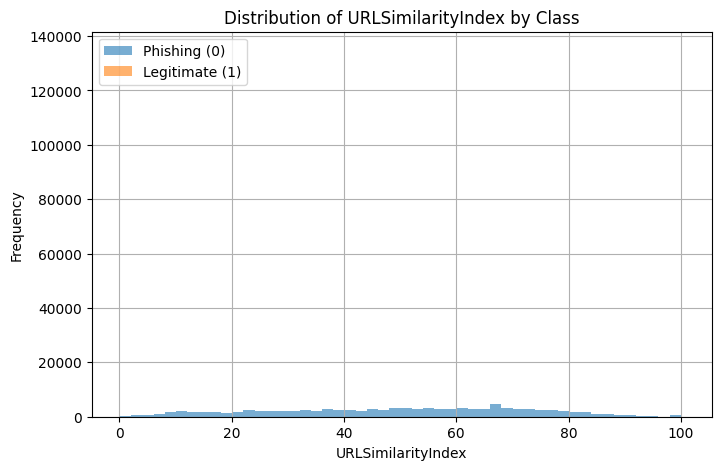

In [8]:
plt.figure(figsize=(8, 5))

df[df["label"] == 0]["URLSimilarityIndex"].plot(
    kind="hist",
    bins=50,
    alpha=0.6,
    label="Phishing (0)"
)

df[df["label"] == 1]["URLSimilarityIndex"].plot(
    kind="hist",
    bins=50,
    alpha=0.6,
    label="Legitimate (1)"
)

plt.xlabel("URLSimilarityIndex")
plt.ylabel("Frequency")
plt.title("Distribution of URLSimilarityIndex by Class")
plt.legend()
plt.grid(True)
plt.show()

URLSimilarityIndex is highly suspicious because it almost perfectly separates the classes.
To avoid relying on an overly informative or potentially unrealistic feature, it was removed from the trusted modeling pipeline.

In [9]:
url_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLegitimateProb",
    "URLCharProb",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "CharContinuationRate"
]

X_url_only = df[url_features]
y_url_only = df["label"]

print("URL-only feature shape:", X_url_only.shape)

URL-only feature shape: (235795, 23)


This URL-only feature set is useful for benchmarking, but it is not fully deployment-ready because some features are not directly extracted from a raw URL string in the final application.

In [10]:
X_train_url, X_test_url, y_train_url, y_test_url = train_test_split(
    X_url_only,
    y_url_only,
    test_size=0.2,
    random_state=42,
    stratify=y_url_only
)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200,
        random_state=42
    )
}


def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba),
        "PR AUC": average_precision_score(y_test, y_proba),
    }


benchmark_results = []

for model_name, model in models.items():
    results = evaluate_model(model, X_train_url, X_test_url, y_train_url, y_test_url)
    results["Model"] = model_name
    benchmark_results.append(results)

benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df = benchmark_df[[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC", "PR AUC"
]]
benchmark_df = benchmark_df.sort_values(by="F1 Score", ascending=False)

benchmark_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
2,HistGradientBoosting,0.997498,0.995827,0.999815,0.997817,0.999524,0.999538
1,Random Forest,0.996904,0.995859,0.998739,0.997297,0.999167,0.998801
0,Logistic Regression,0.996141,0.993806,0.999481,0.996635,0.999001,0.998779


In [11]:
current_path = Path.cwd()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root:", project_root)

from src.model.feature_extractor import extract_url_features

Project root: d:\Github\phishing-ai-ui


In [12]:
extracted_rows = []

for url in df["URL"]:
    features = extract_url_features(url).iloc[0].to_dict()
    extracted_rows.append(features)

X_extracted_url = pd.DataFrame(extracted_rows)
y_extracted_url = df["label"]

print("X_extracted_url shape:", X_extracted_url.shape)
print("y_extracted_url shape:", y_extracted_url.shape)

X_extracted_url.head()

X_extracted_url shape: (235795, 18)
y_extracted_url shape: (235795,)


,URLLength,DomainLength,IsDomainIP,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS
0,32.0,24.0,0.0,3.0,1.0,0.0,0.0,0.0,27.0,0.843750,0.0,0.0,0.0,0.0,0.0,5.0,0.156250,1.0
1,24.0,16.0,0.0,2.0,1.0,0.0,0.0,0.0,18.0,0.750000,0.0,0.0,0.0,0.0,0.0,6.0,0.250000,1.0
2,30.0,22.0,0.0,2.0,2.0,0.0,0.0,0.0,24.0,0.800000,0.0,0.0,0.0,0.0,0.0,6.0,0.200000,1.0
3,27.0,19.0,0.0,3.0,1.0,0.0,0.0,0.0,22.0,0.814815,0.0,0.0,0.0,0.0,0.0,5.0,0.185185,1.0
4,34.0,26.0,0.0,3.0,1.0,0.0,0.0,0.0,29.0,0.852941,0.0,0.0,0.0,0.0,0.0,5.0,0.147059,1.0


This feature matrix is generated using the same feature_extractor.py module that will be used later in the UI.
This avoids training/inference feature mismatch.

In [13]:
extracted_url_features = X_extracted_url.columns.tolist()

X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_extracted_url,
    y_extracted_url,
    test_size=0.2,
    random_state=42,
    stratify=y_extracted_url
)

extractor_based_model = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=5,
    max_iter=300,
    random_state=42
)

extractor_based_model.fit(X_train_ext, y_train_ext)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",5
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtype

In [14]:
y_pred_ext = extractor_based_model.predict(X_test_ext)
y_proba_ext = extractor_based_model.predict_proba(X_test_ext)[:, 1]

ext_accuracy = accuracy_score(y_test_ext, y_pred_ext)
ext_precision = precision_score(y_test_ext, y_pred_ext)
ext_recall = recall_score(y_test_ext, y_pred_ext)
ext_f1 = f1_score(y_test_ext, y_pred_ext)
ext_roc_auc = roc_auc_score(y_test_ext, y_proba_ext)
ext_pr_auc = average_precision_score(y_test_ext, y_proba_ext)
ext_cm = confusion_matrix(y_test_ext, y_pred_ext)

print("Final Extractor-Based Raw URL Model")
print("-" * 50)
print(f"Accuracy  : {ext_accuracy:.4f}")
print(f"Precision : {ext_precision:.4f}")
print(f"Recall    : {ext_recall:.4f}")
print(f"F1 Score  : {ext_f1:.4f}")
print(f"ROC AUC   : {ext_roc_auc:.4f}")
print(f"PR AUC    : {ext_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(ext_cm)

print("\nClassification Report:")
print(classification_report(y_test_ext, y_pred_ext, digits=4))

Final Extractor-Based Raw URL Model
--------------------------------------------------
Accuracy  : 0.9951
Precision : 0.9929
Recall    : 0.9986
F1 Score  : 0.9957
ROC AUC   : 0.9979
PR AUC    : 0.9973

Confusion Matrix:
[[19996   193]
 [   39 26931]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9981    0.9904    0.9942     20189
           1     0.9929    0.9986    0.9957     26970

    accuracy                         0.9951     47159
   macro avg     0.9955    0.9945    0.9950     47159
weighted avg     0.9951    0.9951    0.9951     47159



The final deployment-ready model achieved strong performance while using only features extracted from raw URLs.

Final model:
- HistGradientBoostingClassifier
- Trained on features generated by feature_extractor.py
- Suitable for single URL prediction and batch URL prediction

In [15]:
os.makedirs("../src/model/artifacts", exist_ok=True)

joblib.dump(extractor_based_model, "../src/model/artifacts/raw_url_model.pkl")
joblib.dump(extracted_url_features, "../src/model/artifacts/raw_url_features.pkl")

print("Final raw URL model and feature list saved successfully.")

Final raw URL model and feature list saved successfully.


In [16]:
from src.model.inference import predict_from_url

test_urls = [
    "https://www.google.com",
    "https://example.com/login?user=test&id=123",
    "paypal-security-check.com/login",
    "http://free-gift-card-login.ru/verify?account=123",
    "http://192.168.1.1/login"
]

for url in test_urls:
    print("=" * 80)
    print("URL:", url)
    display(predict_from_url(url))

URL: https://www.google.com


,prediction,prediction_label,phishing_probability,legitimate_probability
0,1,Legitimate,0.00234,0.99766


URL: https://example.com/login?user=test&id=123


,prediction,prediction_label,phishing_probability,legitimate_probability
0,0,Phishing,1.0,9.634176e-13


URL: paypal-security-check.com/login


,prediction,prediction_label,phishing_probability,legitimate_probability
0,0,Phishing,1.0,2.983793e-09


URL: http://free-gift-card-login.ru/verify?account=123


,prediction,prediction_label,phishing_probability,legitimate_probability
0,0,Phishing,1.0,5.072649e-12


URL: http://192.168.1.1/login


,prediction,prediction_label,phishing_probability,legitimate_probability
0,0,Phishing,1.0,1.991146e-08


In [17]:
sample_raw_urls = pd.DataFrame({
    "URL": [
        "https://www.google.com",
        "https://example.com/login?user=test&id=123",
        "paypal-security-check.com/login",
        "http://free-gift-card-login.ru/verify?account=123",
        "http://192.168.1.1/login"
    ]
})

sample_raw_urls.to_csv("../data/processed/sample_raw_urls.csv", index=False)

print("Sample raw URLs CSV saved successfully.")

Sample raw URLs CSV saved successfully.


In [18]:
raw_batch_output = pd.read_csv("../reports/sample_raw_url_predictions.csv")
raw_batch_output

,URL,prediction,prediction_label,phishing_probability,legitimate_probability
0,https://www.google.com,1,Legitimate,0.00234,9.976597e-01
1,https://example.com/login?user=test&id=123,0,Phishing,1.00000,9.634176e-13
2,paypal-security-check.com/login,0,Phishing,1.00000,2.983793e-09
3,http://free-gift-card-login.ru/verify?account=123,0,Phishing,1.00000,5.072649e-12
4,http://192.168.1.1/login,0,Phishing,1.00000,1.991146e-08


In [19]:
raw_batch_output[[
    "URL",
    "prediction",
    "prediction_label",
    "phishing_probability",
    "legitimate_probability"
]]

,URL,prediction,prediction_label,phishing_probability,legitimate_probability
0,https://www.google.com,1,Legitimate,0.00234,9.976597e-01
1,https://example.com/login?user=test&id=123,0,Phishing,1.00000,9.634176e-13
2,paypal-security-check.com/login,0,Phishing,1.00000,2.983793e-09
3,http://free-gift-card-login.ru/verify?account=123,0,Phishing,1.00000,5.072649e-12
4,http://192.168.1.1/login,0,Phishing,1.00000,1.991146e-08
